# Simulating manual patch clamp experiments

In the [last notebook](./2-compensation.ipynb) we completed our model of whole-cell patch clamp in voltage-clamp mode.
Here, we use this model to simulate a manual patch clamp experiment.

## Pipette in the bath

We start by modelling a pipette hanging in the bath, but not touching a cell.
We've found a cell and brought the pipette close, but not near enough to affect the current reading yet.

We'll assume $R_s$ is dominated by the pipette resistance, which we'll set to $4M\Omega$.
The variables representing the cell have been removed, and no compensations will be used except C-fast compensation (which is off at this point).

<img src="./img/vc-bath.png" />

_**Figure 1**: A reduced model, showing the pipette in the bath. The resistor $R_s$ here represents only the pipette resistance (i.e. the resistance from the internal to the external electrode, via the pipette tip and solutions)._

The equations for this model are

\begin{align}
\dot{V}_s = \frac{V_c - V_s}{\tau_s}
\end{align}
and
\begin{align}
I_\text{obs} = (C_p - C_p^*) \dot{V}_s + \frac{V_s + E_\text{off}^\dagger}{R_s}
\end{align}

it is implemented in [vc-bath.mmt](./res/vc-bath.mmt).

In [1]:
import colorsys
import myokit
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
m = myokit.load_model('./res/vc-bath.mmt')
m.check_units(myokit.UNIT_STRICT)

In [3]:
p = myokit.Protocol()
p.add_step(level=0, duration=5)
p.add_step(level=10, duration=10)
p.add_step(level=0, duration=15)

s = myokit.Simulation(m, p)
s.pre(4)
d = s.run(20, log_interval=1e-3)

In [4]:
def create_plot(label1='V (mV)', label2='$I_{obs}$ (pA)', av1=[], av2=[]):
    """ Sets up a two axes plot, with horizontal lines at av1 and av2. """
    kw = dict(color='#aaa', ls='--')
    fig = plt.figure(figsize=(15, 6))
    
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.set_ylabel(label1)
    for y in av1:
        ax1.axhline(y, **kw)
    
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.set_xlabel('Time (ms)')
    ax2.set_ylabel(label2)
    for y in av2:
        ax2.axhline(y, **kw)
    
    return fig, ax1, ax2

blue_hls = colorsys.rgb_to_hls(*matplotlib.colors.ColorConverter.to_rgb('tab:blue'))
def blue(f):
    h, l, s = blue_hls
    return colorsys.hls_to_rgb(
        blue_hls[0], 1 - f * (1 - blue_hls[1]), blue_hls[2])

orange_hls = colorsys.rgb_to_hls(*matplotlib.colors.ColorConverter.to_rgb('tab:orange'))
def orange(f):
    h, l, s = orange_hls
    return colorsys.hls_to_rgb(
        orange_hls[0], 1 - f * (1 - orange_hls[1]), orange_hls[2])

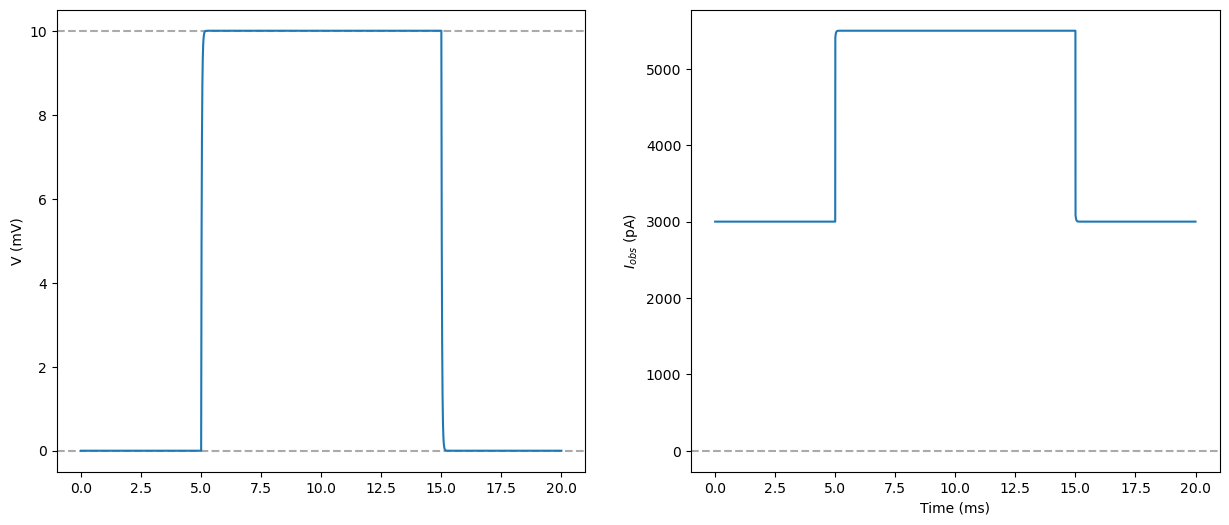

In [5]:
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0])
ax1.plot(d.time(), d['amp.Vs'])
ax2.plot(d.time(), d['amp.I_obs'])
plt.show()

On the left, we see our test pulse: a very brief jump from 0mV to 10mV and back.

On the right, we see the resulting current.

There is a considerable current when we apply 0mV, so the first thing we need to do is zero the current.

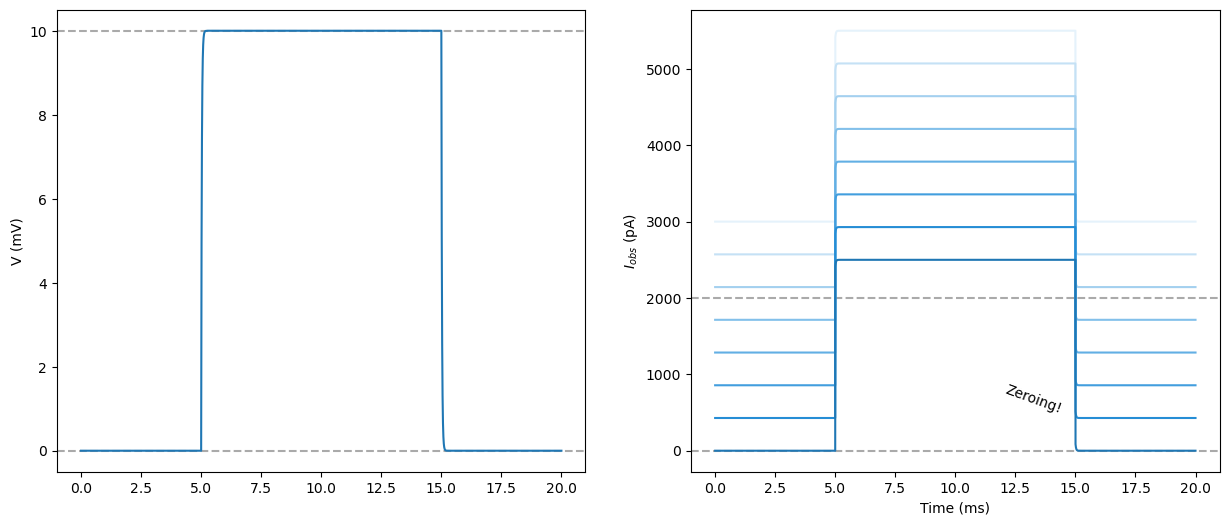

In [6]:
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0, 2000])
for E in np.linspace(12, 0, 8):
    s.reset()
    s.set_constant('amp.E_off', E)
    s.pre(4)
    d = s.run(20, log_interval=1e-3)
    ax2.plot(d.time(), d['amp.I_obs'], color=blue(1 - 0.9 * (E / 12)))
ax1.plot(d.time(), d['amp.Vs'])
ax2.text(12, 500, 'Zeroing!', rotation=-20)
plt.show()

Let's look at the result:

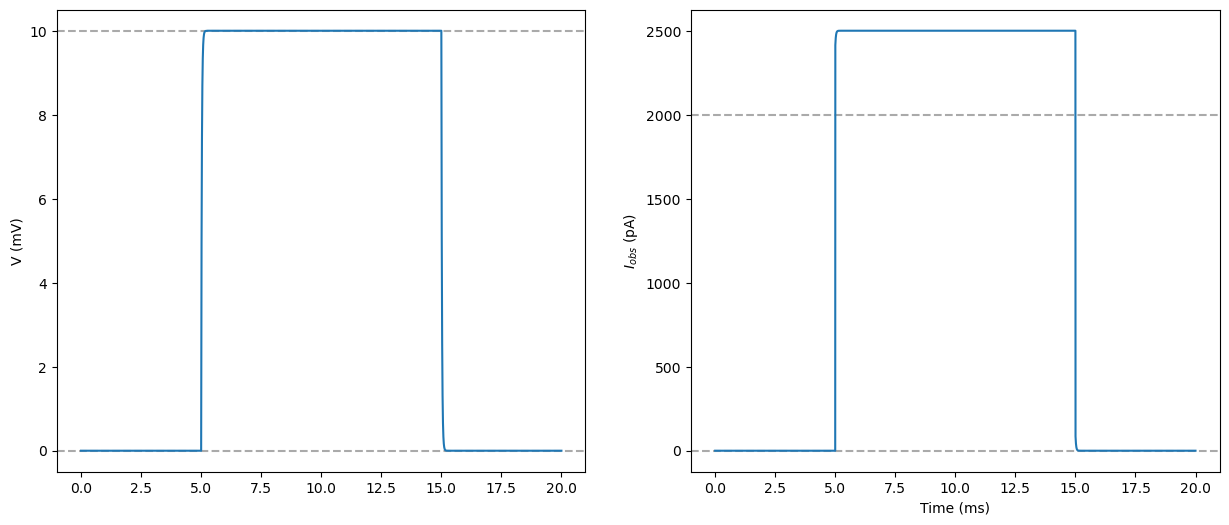

In [7]:
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0, 2000])
ax1.plot(d.time(), d['amp.Vs'])
ax2.plot(d.time(), d['amp.I_obs'])
plt.show()

On the left, we see that the pipette voltage follows the command voltage rapidly.

On the right, we see a current of either 0 or 10mV / 4MOhm = 2.5nA.
It rises and falls rapidly, hindered only by the charging of $C_f$.
Note that we do not yet see strong capacitative transients at this point.

## Touching the cell

Now, we gently move the pipette against the cell membrane.
This blocks the pipette opening, greatly increasing $R_s$.
We'll assume it goes up to 50MOhm, and use the same model as above.

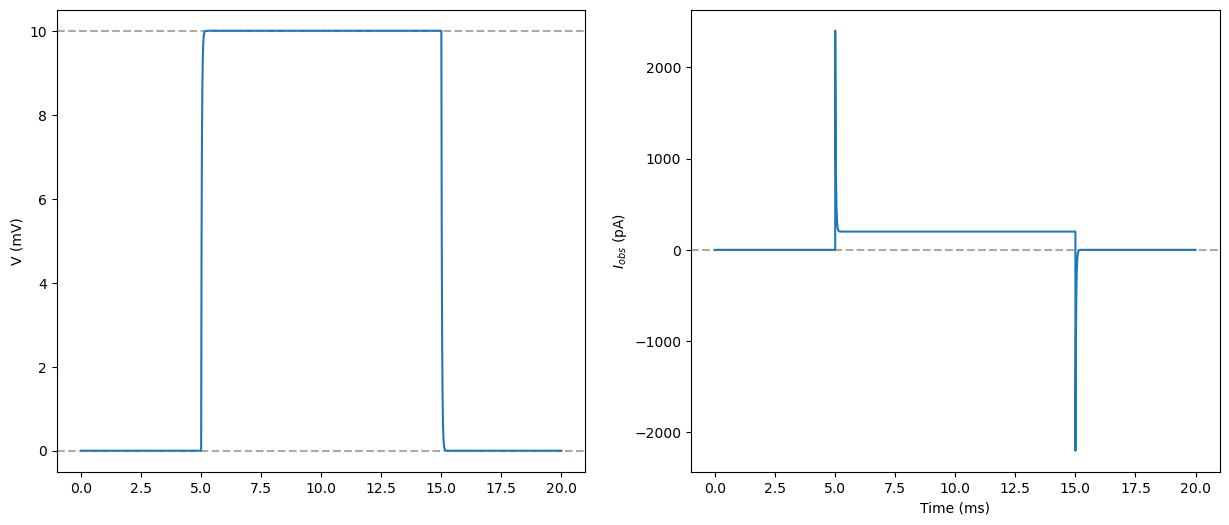

In [8]:
s.reset()
s.set_constant('amp.Rs', 0.05)
d = s.run(20, log_interval=1e-3)
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0])
ax1.plot(d.time(), d['amp.Vs'])
ax2.plot(d.time(), d['amp.I_obs'])
plt.show()

With this new, higher, resistance, the fast-capacitance artefacts become clearly visible.

## A giga-ohm seal

We apply more virtual suction, and create a giga-ohm seal. Let's use 2GOhm.

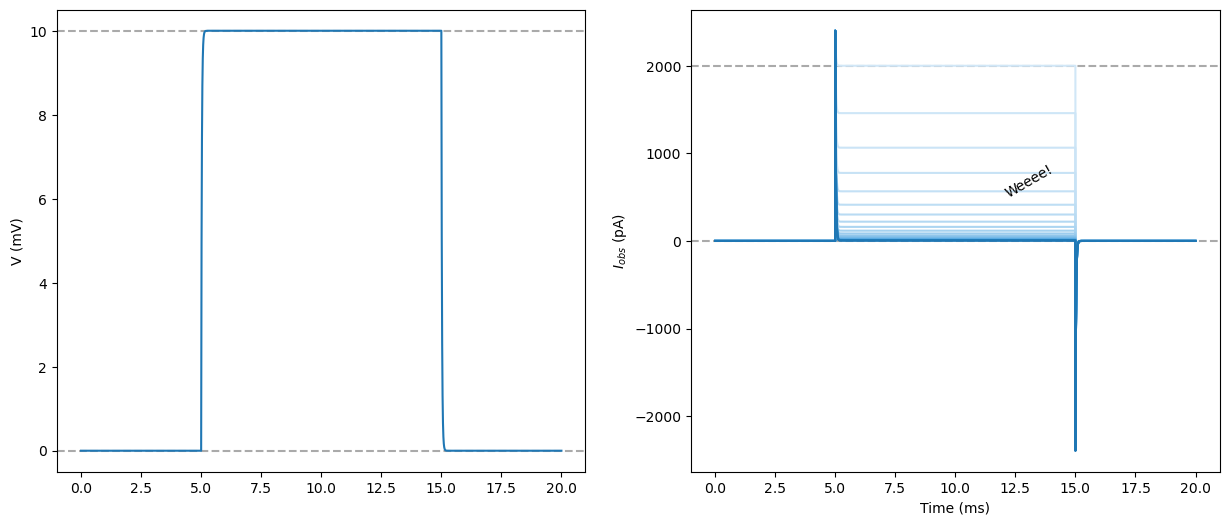

In [9]:
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0, 2000])
for Rs in np.geomspace(5e-3, 2, 20):
    s.reset()
    s.set_constant('amp.Rs', Rs)
    d = s.run(20, log_interval=1e-3)
    ax2.plot(d.time(), d['amp.I_obs'], color=blue(0.1 + 0.9 * (Rs / 2)**0.4))
ax1.plot(d.time(), d['amp.Vs'])
ax2.plot(d.time(), d['amp.I_obs'], color='tab:blue')
ax2.text(12, 500, 'Weeee!', rotation=30)
plt.show()

## Fast transient cancellation

The signal now looks like this:

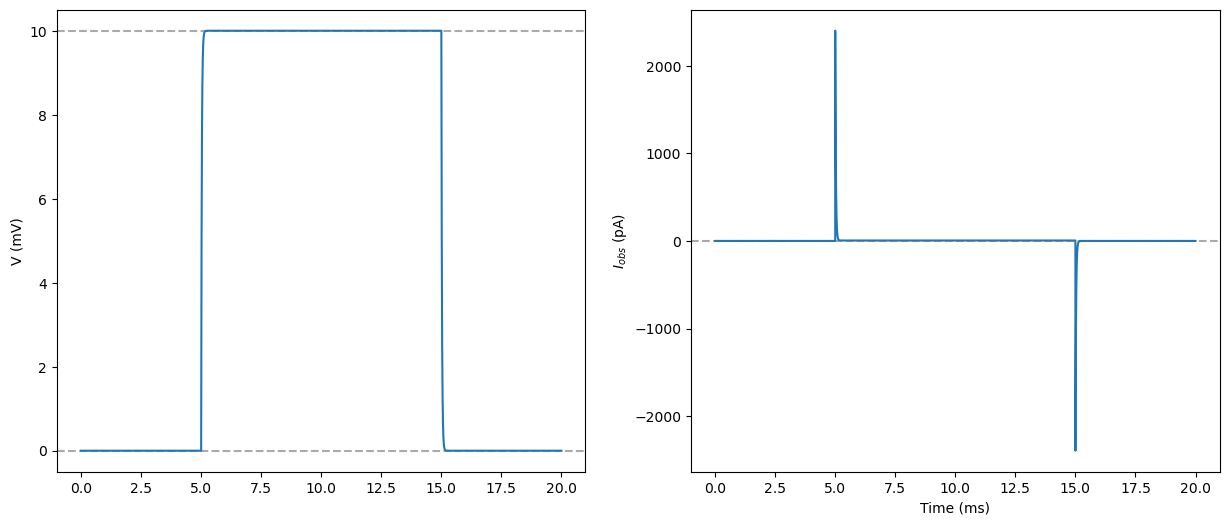

In [10]:
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0])
ax1.plot(d.time(), d['amp.Vs'])
ax2.plot(d.time(), d['amp.I_obs'])
plt.show()

So it's time to zoom in, and switch the fast capacitative transient cancellation on:

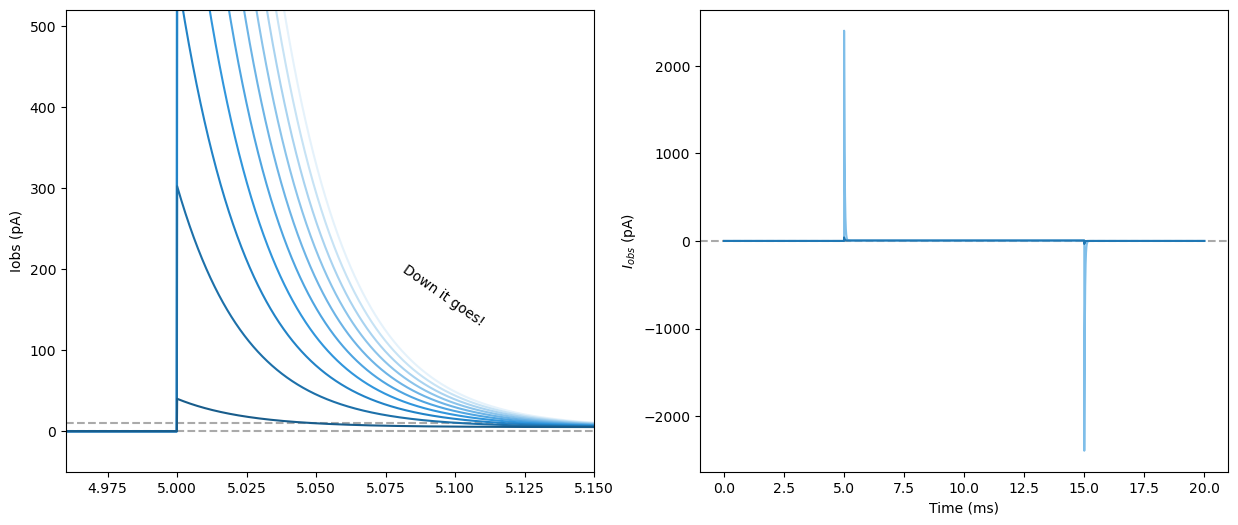

In [11]:
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0], label1='Iobs (pA)')
for Cp_est in np.linspace(0, 5.9, 10):
    s.reset()
    s.set_constant('amp.Cp_est', Cp_est)
    d = s.run(20, log_interval=1e-4).npview()
    ax1.plot(d.time(), d['amp.I_obs'], color=blue(0.1 + 0.9 * Cp_est / 5))
    if Cp_est == 0:
        ax2.plot(d.time(), d['amp.I_obs'], color=blue(0.5))
ax1.set_xlim(4.96, 5.15)
ax1.set_ylim(-50, 520)
ax1.text(5.08, 130, 'Down it goes!', rotation=-35)
ax2.plot(d.time(), d['amp.I_obs'], color=blue(1))
plt.show()

In the simplified model above, a perfect compensation can be achieved. But we'll leave a small bit in for realism, so that the end result looks like this:

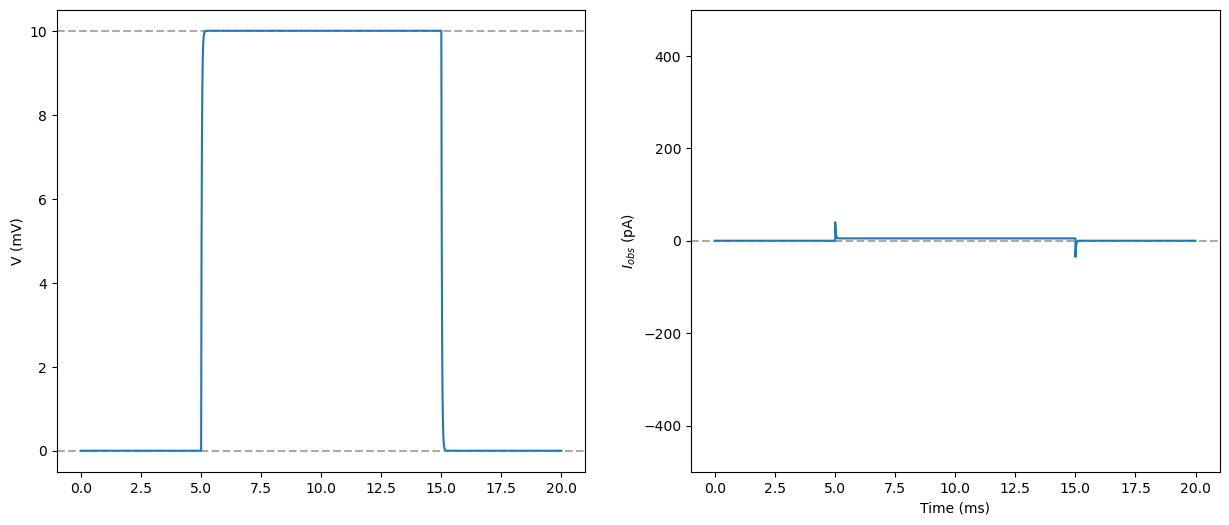

In [12]:
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0])
ax1.plot(d.time(), d['amp.Vs'])
ax2.plot(d.time(), d['amp.I_obs'])
ax2.set_ylim(-500, 500)
plt.show()

In practice, there will usually be

- Some remaining capacitance artefacts. This can be due to multiple artefacts being present in the data (each with their own $C$, and often with slight delays). Depending on the amplifier and the skill of the patch clamper, the main one or two will be cancelled out, but some artefact is likely to remain.
- Noise. This can hide remaining artefacts, but with a good seal can only hide the step up from zero completely.

A more realistic trace might look like this:

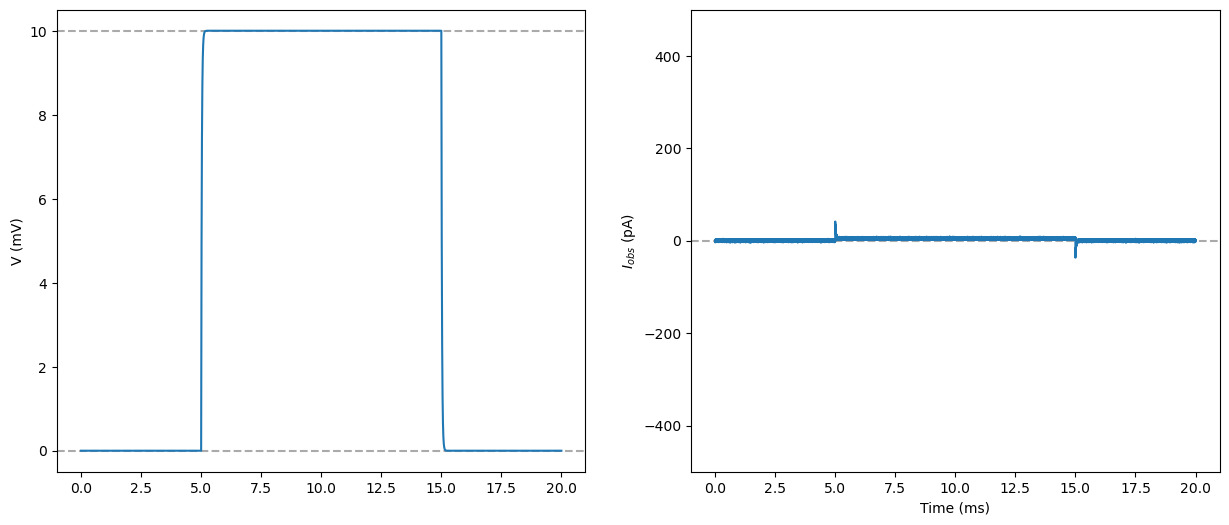

In [13]:
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0])
ax1.plot(d.time(), d['amp.Vs'])
ax2.plot(d.time(), d['amp.I_obs'] + np.random.normal(0, 1, d.time().shape))
ax2.set_ylim(-500, 500)
plt.show()

(Note that the noise we simulate here is _noise remaining after low-pass filtering_. The noise before filtering is usually much larger.)

## Breaking the seal: access to the cell

Next, we break the seal and gain access to the cell!

To simulate this, we need the full model.
We shall assume the same $C_p$ value and compensation as above, but add a membrane with a resistance of 500M$\Omega$ and a capacitance of 50pF.
The access resistance will be slightly higher than before we connected to the cell, we will use 8M$\Omega$.
Finally, we assume a small leak current exists through the seal.

In [14]:
# Load the model
m = myokit.load_model('../models-mmt/vc-level-0.mmt')
# Replace the "ionic current" with an equation for membrane resistance current
m.get('amp.I').set_rhs('Vm / 0.5 [GOhm]')
# Check for any issues
m.check_units(myokit.UNIT_STRICT)

In [15]:
s = myokit.Simulation(m, p)
# Use same Eoff, Cp and Cp_est as above
s.set_constant('amp.E_off', 0)
s.set_constant('amp.Cp', 6)
s.set_constant('amp.Cp_est', 5.9)

# Use a higher access resistance, including patch as well as pipette
s.set_constant('amp.Rs', 8e-3)

# Set a membrane capacitance, but no compensation
s.set_constant('amp.Cm', 50)
s.set_constant('amp.Cm_est', 0)

# Disable series resistance compensation - for now
s.set_constant('amp.alpha', 0)
s.set_constant('amp.beta', 0)

# Add a small leak current, reversing at 0mV
s.set_constant('amp.g_leak', 0.1)

# Set initial voltages to 0 and pre-pace
s.set_state([0] * m.count_states())
s.pre(4)

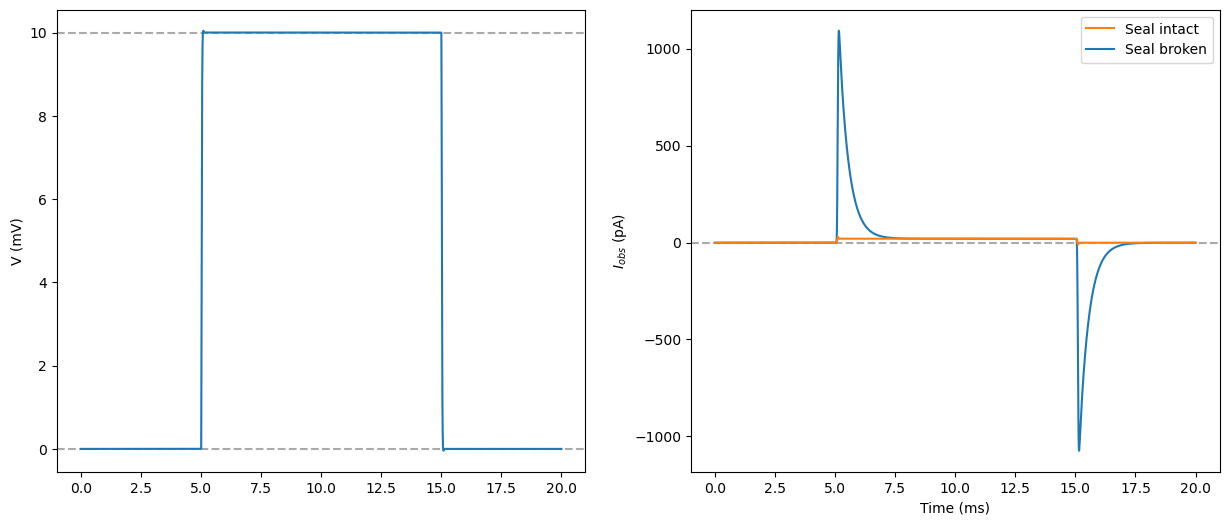

In [16]:
fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0])
s.reset()
s.set_constant('amp.Cm', 1e-3)
d = s.run(20, log_interval=1e-4).npview()
ax2.plot(d.time(), d['amp.I_obs'], color='tab:orange', label='Seal intact', zorder=3)
s.reset()
s.set_constant('amp.Cm', 50)
d = s.run(20).npview()
ax2.plot(d.time(), d['amp.I_obs'], color=blue(1), label='Seal broken')
ax2.legend()
ax1.plot(d.time(), d['amp.Vs'])
plt.show()

We have gained access to the cell! This is visible by the sharp and sudden appearance of a large capacitative current.

In simulations, we can also observe the membrane potential at this point:

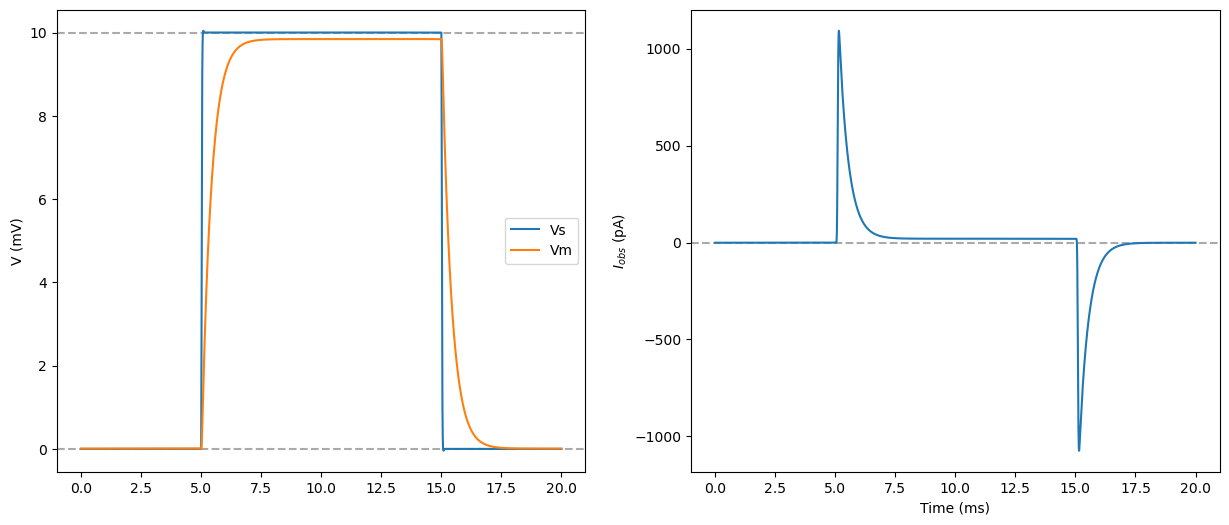

In [17]:
s.reset()
d = s.run(20, log_interval=1e-4).npview()

fig, ax1, ax2 = create_plot(av1=[0, 10], av2=[0])
ax1.plot(d.time(), d['amp.Vs'], label='Vs')
ax1.plot(d.time(), d['amp.Vm'], label='Vm')
ax1.legend()
ax2.plot(d.time(), d['amp.I_obs'], color=blue(1))
plt.show()

This shows us how the observed current charges the membrane.

## Slow transient cancellation

To cancel out this transient, we first need to estimate its time constant $\tau = R_s C_m$.
Various methods exist to esimate $\tau$ directly, or to estimate $R_s$ and $C_m$ (which is useful for series resistance compensation later on).
These are usually implemented in patch clamp software, so we will assume reasonable estimates are available.

Below, we show the effect of setting $R_s^*$ and then "dialing in" the $C_m$ estimate $C_m^*$.

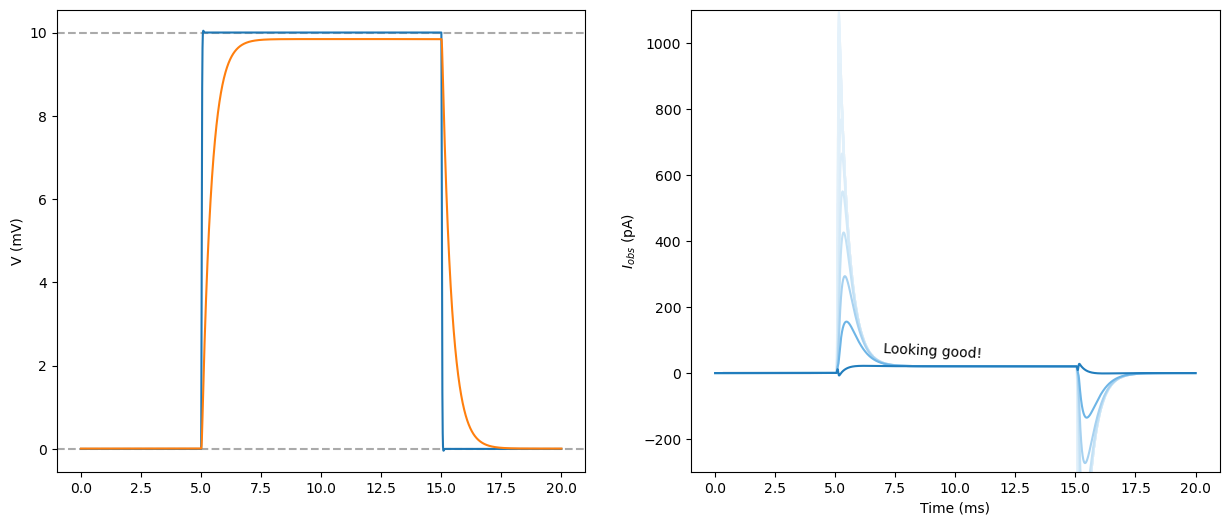

In [18]:
# Set a membrane resistance estimate
s.set_constant('amp.Rs_est', 7.9e-3)

# Add a Cm estimate for Cm compensation
fig, ax1, ax2 = create_plot(av1=[0, 10])
for Cm_est in np.geomspace(1, 50, 14) - 1:
    s.reset()
    s.set_constant('amp.Cm_est', Cm_est)
    d = s.run(20, log_interval=1e-3)  
    ax2.plot(d.time(), d['amp.I_obs'], color=blue(0.1 + 0.9 * (Cm_est / 50)**2))
ax1.plot(d.time(), d['amp.Vs'])
ax1.plot(d.time(), d['amp.Vm'])
ax2.text(7, 45, 'Looking good!', rotation=-3)
ax2.set_ylim(-300, 1100)
plt.show()

At this point we should see something like this:

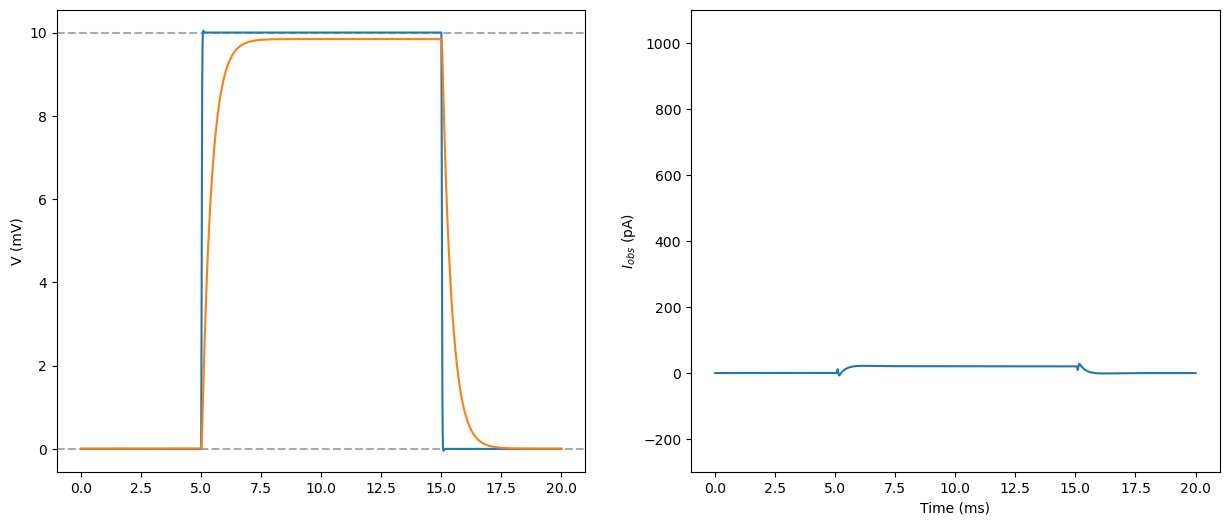

In [19]:
fig, ax1, ax2 = create_plot(av1=[0, 10])
ax1.plot(d.time(), d['amp.Vs'])
ax1.plot(d.time(), d['amp.Vm'])
ax2.plot(d.time(), d['amp.I_obs'])
ax2.set_ylim(-300, 1100)
plt.show()

Note that the $V_m$ behaviour hasn't changed! We're still charging the membrane, just as before, but now the charging current comes through a separate pathway and does not show up in our measured current.

The corrected current gets less pretty when we zoom in on it:

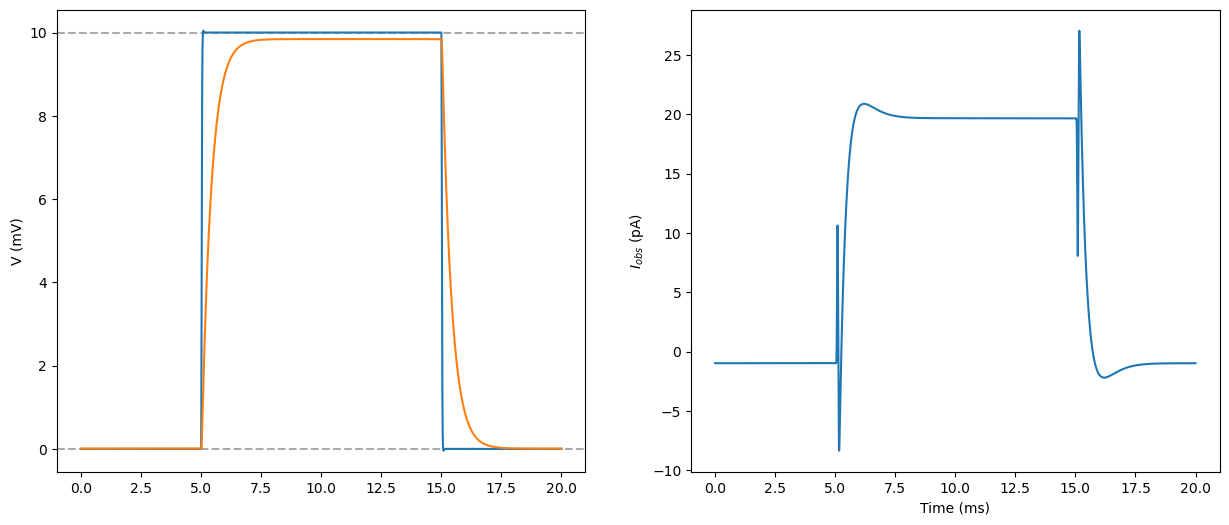

In [20]:
fig, ax1, ax2 = create_plot(av1=[0, 10])
ax1.plot(d.time(), d['amp.Vs'])
ax1.plot(d.time(), d['amp.Vm'])
ax2.plot(d.time(), d['amp.I_obs'])
plt.show()

Although as before, noise can hide some of the fast behaviours at this point:

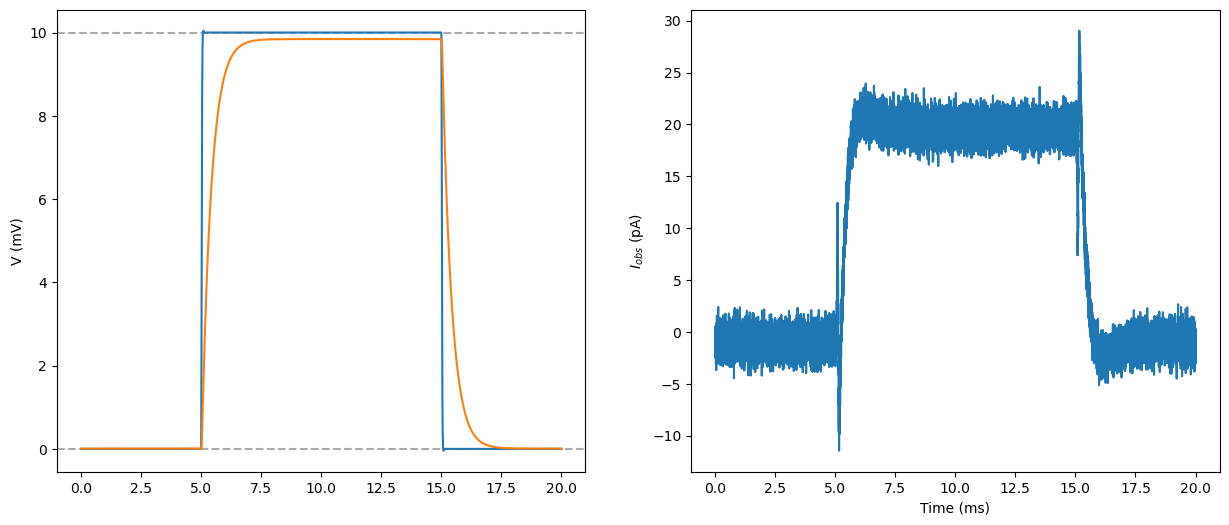

In [21]:
fig, ax1, ax2 = create_plot(av1=[0, 10])
ax1.plot(d.time(), d['amp.Vs'])
ax1.plot(d.time(), d['amp.Vm'])
ax2.plot(d.time(), d['amp.I_obs'] + np.random.normal(0, 1, len(d.time())))
plt.show()

## Series resistance correction

In the next step, we add series resistance compensation, **first by using only correction, not prediction**.
This is for illustrative purposes alone: in a real experiment you typically set correction and prediction at the same time.

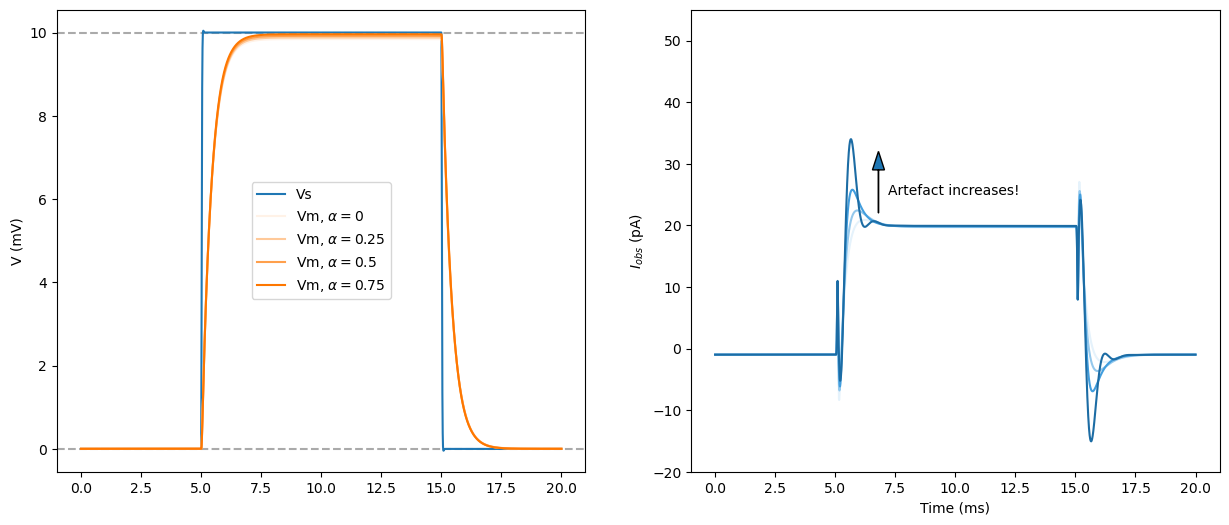

In [22]:
fig, ax1, ax2 = create_plot(av1=[0, 10])
ax1.plot(d.time(), d['amp.Vs'], label='Vs')
s.set_constant('amp.beta', 0)
for alpha in (0, 0.25, 0.5, 0.75):
    s.reset()
    s.set_constant('amp.alpha', alpha)
    s.pre(4)
    d = s.run(20, log_interval=1e-3)  
    ax1.plot(d.time(), d['amp.Vm'], color=orange(0.1 + 0.9 * (alpha / 0.7)), label=rf'Vm, $\alpha={alpha}$')
    ax2.plot(d.time(), d['amp.I_obs'], color=blue(0.1 + 0.9 * (alpha / 0.7)))
ax2.set_ylim(-20, 55)
ax2.arrow(6.8, 22, 0, 7, head_width=0.5, head_length=3)
ax2.text(7.2, 25, 'Artefact increases!')
ax1.legend()
plt.show()

This is a tricky step to do in practice, because our beautifully compensated artefact now actually increases!

What's happening? On the left, we've plotted the membrane potential, which is not visible in real experiments.
As can be seen, this increases as the percentage correction is increased.
As a result, the voltage step gets larger, and so the artefacts due to the step increase too.

So the beneficial actions of series resistance compensation - reducing the voltage drop through $R_s$ and making the applied step more like the intended step - are not visible as "positive" changes to the observed current.

Next, we'll show what happens when you set "correction" and "prediction" simultaneously (as is done on most amplifiers).

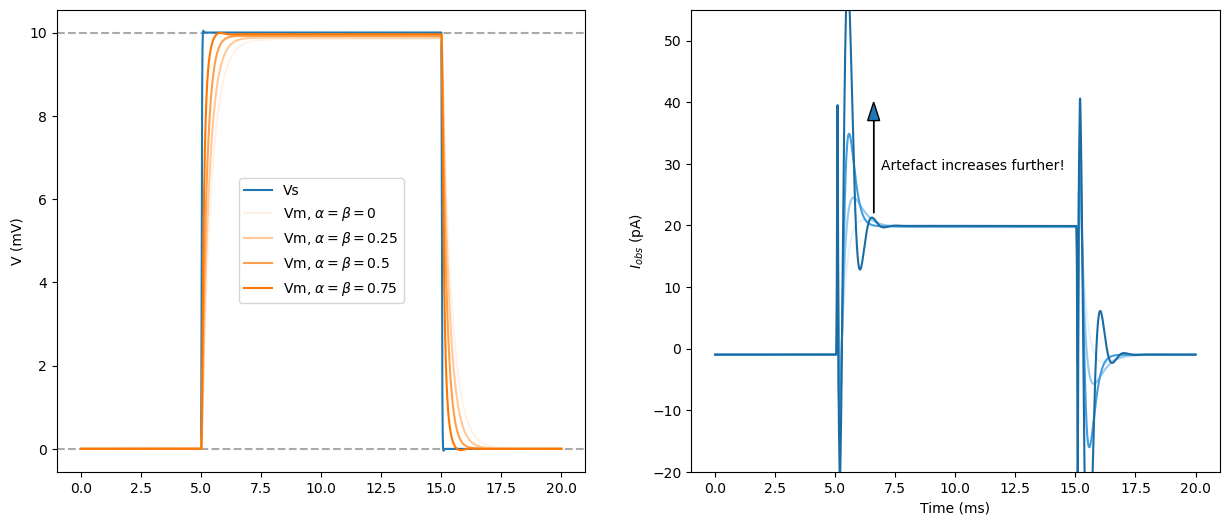

In [23]:
fig, ax1, ax2 = create_plot(av1=[0, 10])
ax1.plot(d.time(), d['amp.Vs'], label='Vs')
for alpha in (0, 0.25, 0.5, 0.75):
    s.reset()
    s.set_constant('amp.alpha', alpha)
    s.set_constant('amp.beta', alpha)
    s.pre(4)
    d = s.run(20, log_interval=1e-3)  
    ax1.plot(d.time(), d['amp.Vm'], color=orange(0.1 + 0.9 * (alpha / 0.7)), label=rf'Vm, $\alpha=\beta={alpha}$')
    ax2.plot(d.time(), d['amp.I_obs'], color=blue(0.1 + 0.9 * (alpha / 0.7)))
ax2.set_ylim(-20, 55)
ax2.arrow(6.6, 22, 0, 15, head_width=0.5, head_length=3)
ax2.text(6.9, 29, 'Artefact increases further!')
ax1.legend()
plt.show()

Now the observed current gets even messier: the artefact gets larger still and a damped oscillation appears.
But on the left, we can see how the step gets steeper and closer to the intended voltage.

So with these settings there is a trade-off between (1) obtaining the "perfect" voltage step", (2) reducing artefacts (and thus unuseable signal) in the measured current.

### Final tweaks?

If we're feeling brave, we might also try improving the previous compensation settings at this point.
This is not that easy to do, as the effect of getting everything right is not immediately obvious:

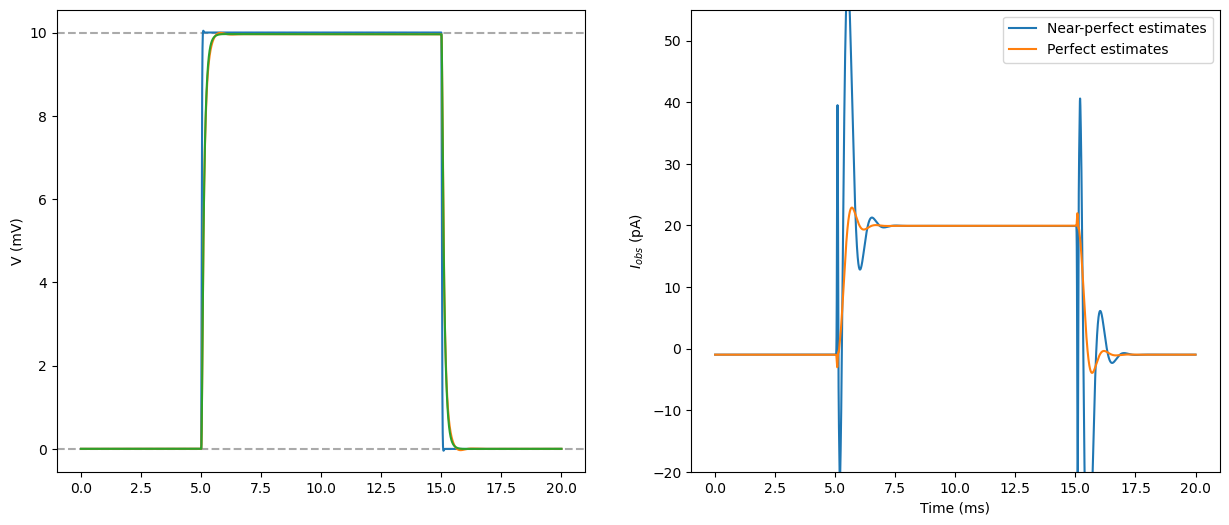

In [24]:
fig, ax1, ax2 = create_plot(av1=[0, 10])
ax1.plot(d.time(), d['amp.Vs'], label='Vs')

s.set_constant('amp.Cp_est', 5.9)
s.set_constant('amp.Rs_est', 7.9e-3)
s.set_constant('amp.Cm_est', 49)
s.reset()
s.pre(4)
d = s.run(20, log_interval=1e-3)  
ax1.plot(d.time(), d['amp.Vm'], label='Vm')
ax2.plot(d.time(), d['amp.I_obs'], label='Near-perfect estimates')

s.set_constant('amp.Cp_est', 6)
s.set_constant('amp.Rs_est', 8e-3)
s.set_constant('amp.Cm_est', 50)
s.reset()
s.pre(4)
d = s.run(20, log_interval=1e-3)  
ax1.plot(d.time(), d['amp.Vm'], label='Vm')
ax2.plot(d.time(), d['amp.I_obs'], label='Perfect estimates')

ax2.set_ylim(-20, 55)
ax2.legend()
plt.show()

And introducing errors, especially in $C_p^*$ can make the signal much worse.

Finally, with some noise and really good estimates, you might expect to see something like this:

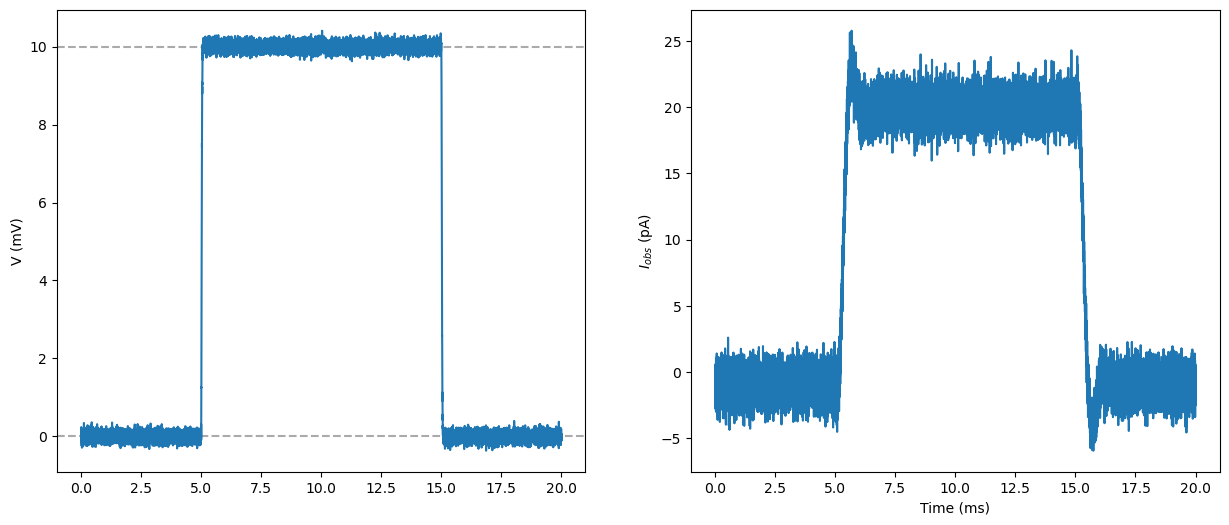

In [25]:
fig, ax1, ax2 = create_plot(av1=[0, 10])
s.set_constant('amp.Cp_est', 6)
s.set_constant('amp.Rs_est', 8e-3)
s.set_constant('amp.Cm_est', 50)
s.reset()
s.pre(4)
d = s.run(20, log_interval=1e-3)  
ax1.plot(d.time(), d['amp.Vs'] + np.random.normal(0, 0.1, len(d.time())))
ax2.plot(d.time(), d['amp.I_obs'] + np.random.normal(0, 1, len(d.time())))
plt.show()

## Conclusion

In this notebook, we
- Used a simplified model of a voltage-clamp set-up to simulate the early stages of a patch-clamp experiment: zeroing, approaching the cell, making contact, and configuring fast-capacitance cancellation
- Used the full model of voltage-clamp developed in the previous notebook to run a simulation of the next stages: breaking the seal, slow capacitance cancellation, and series resistance compensation.

Having shown what it can do, in the [next notebook](./4-simplifications.ipynb) we will look at how the model can be simplified.